In [1]:
# Cell 1: Cleaning, feature engineering and group-aware split (Table 4.1)
from pathlib import Path
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedGroupKFold

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_RAW = ROOT / "data" / "raw" / "hotels.csv"
DATA_PROC = ROOT / "data" / "processed"
FIG_DIR = ROOT / "figures"
TAB_DIR = ROOT / "tables"
RANDOM_STATE = 42
TARGET = "is_canceled"
sns.set_theme(style="whitegrid")

df = pd.read_csv(DATA_RAW)
log = []

def log_step(stage, action, affected):
    log.append({"Stage": stage, "Action": action,
                "Records affected": affected, "Rows remaining": f"{len(df):,}"})

log_step("Start", "Load raw dataset", f"{len(df):,} rows")

# 1. Leakage removal
df = df.drop(columns=["reservation_status", "reservation_status_date", "assigned_room_type"])
log_step("Leakage removal", "Drop reservation_status, reservation_status_date, assigned_room_type", "3 columns")

# 2. Noise reduction: remove clearly invalid records only
guests = df["adults"] + df["children"].fillna(0) + df["babies"]
invalid_rules = [
    ("Remove bookings with zero guests", guests == 0),
    ("Remove negative ADR", df["adr"] < 0),
    ("Remove ADR above 1,000", df["adr"] > 1000),
    ("Remove bookings with ten or more adults", df["adults"] >= 10),
    ("Remove 'Undefined' market segment or channel",
     df["market_segment"].eq("Undefined") | df["distribution_channel"].eq("Undefined")),
]
for action, mask in invalid_rules:
    mask = mask.reindex(df.index, fill_value=False)
    df = df[~mask]
    log_step("Noise reduction", action, f"{int(mask.sum()):,}")

# 3. Imputation and recoding (preserving the signal in missingness)
n = int(df["children"].isna().sum())
df["children"] = df["children"].fillna(0)
log_step("Imputation", "Fill missing children with 0 (mode)", f"{n:,}")

n = int(df["country"].isna().sum())
df["country"] = df["country"].fillna("Unknown")
log_step("Imputation", "Fill missing country with explicit 'Unknown' category", f"{n:,}")

n = int(df["agent"].isna().sum())
df["agent"] = df["agent"].map(lambda v: "none" if pd.isna(v) else str(int(v)))
log_step("Imputation", "Encode missing agent as explicit 'none' category", f"{n:,}")

n = int(df["company"].isna().sum())
df["has_company"] = df["company"].notna().astype(int)
df = df.drop(columns="company")
log_step("Imputation", "Replace company ID (94% missing) with has_company flag", f"{n:,}")

n = int((df["meal"] == "Undefined").sum())
df.loc[df["meal"] == "Undefined", "meal"] = "SC"
log_step("Recoding", "Recode meal 'Undefined' as 'SC' (same meaning)", f"{n:,}")

# 4. Feature engineering
month_map = {m: i for i, m in enumerate(
    ["January", "February", "March", "April", "May", "June", "July",
     "August", "September", "October", "November", "December"], start=1)}
arrival = pd.to_datetime(pd.DataFrame({"year": df["arrival_date_year"],
                                       "month": df["arrival_date_month"].map(month_map),
                                       "day": df["arrival_date_day_of_month"]}))
df["total_nights"] = df["stays_in_weekend_nights"] + df["stays_in_week_nights"]
df["total_guests"] = df["adults"] + df["children"] + df["babies"]
df["has_previous_cancellation"] = (df["previous_cancellations"] > 0).astype(int)
df["arrival_dayofweek"] = arrival.dt.dayofweek.values
log_step("Feature engineering",
         "Add total_nights, total_guests, has_previous_cancellation, arrival_dayofweek", "4 columns")

# 5. Group-aware split: identical bookings share a group and stay on one side
features = [c for c in df.columns if c != TARGET]
df = df.reset_index(drop=True)
group_id = pd.util.hash_pandas_object(df[features], index=False).values
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
train_idx, test_idx = next(sgkf.split(df[features], df[TARGET], groups=group_id))
train_df, test_df = df.iloc[train_idx].copy(), df.iloc[test_idx].copy()
groups_train = group_id[train_idx]

df.to_csv(DATA_PROC / "hotels_clean.csv", index=False)
table_4_1 = pd.DataFrame(log)
table_4_1.to_csv(TAB_DIR / "table4.1_cleaning_log.csv", index=False)

print("Cleaning log:")
print(table_4_1.to_string(index=False))
print(f"\nClean dataset: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Duplicate groups: {len(np.unique(group_id)):,} unique feature patterns")
print(f"\nTrain: {len(train_df):,} rows | cancelled = {train_df[TARGET].mean()*100:.2f}%")
print(f"Test : {len(test_df):,} rows | cancelled = {test_df[TARGET].mean()*100:.2f}%")
overlap = len(set(group_id[train_idx]) & set(group_id[test_idx]))
print(f"Groups appearing in both train and test: {overlap}")

Cleaning log:
              Stage                                                                       Action Records affected Rows remaining
              Start                                                             Load raw dataset     119,390 rows        119,390
    Leakage removal         Drop reservation_status, reservation_status_date, assigned_room_type        3 columns        119,390
    Noise reduction                                             Remove bookings with zero guests              180        119,210
    Noise reduction                                                          Remove negative ADR                1        119,209
    Noise reduction                                                       Remove ADR above 1,000                1        119,208
    Noise reduction                                      Remove bookings with ten or more adults               13        119,195
    Noise reduction                                 Remove 'Undefined' market segme

In [2]:
# Cell 2: Experiment framework and duplicate handling (Table 4.2)
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (f1_score, precision_score, recall_score,
                             roc_auc_score, average_precision_score)

cat_cols = train_df[features].select_dtypes(exclude="number").columns.tolist()
num_cols = train_df[features].select_dtypes(include="number").columns.tolist()


def make_models():
    return {
        "Logistic Regression": LogisticRegression(max_iter=3000),
        "Random Forest": RandomForestClassifier(n_estimators=100, n_jobs=-1,
                                                random_state=RANDOM_STATE),
    }


def baseline_prep(num=None, cat=None):
    """Baseline preprocessing: standardise numbers, one-hot encode with rare-level grouping."""
    num = num_cols if num is None else num
    cat = cat_cols if cat is None else cat
    return ColumnTransformer([
        ("num", StandardScaler(), num),
        ("cat", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=0.005), cat),
    ])


def evaluate(pipe, Xtr, ytr, Xte, yte):
    """Fit a pipeline and return test-set metrics plus training time."""
    start = time.perf_counter()
    pipe.fit(Xtr, ytr)
    train_time = time.perf_counter() - start
    prob = pipe.predict_proba(Xte)[:, 1]
    pred = (prob >= 0.5).astype(int)
    return {
        "F1": round(f1_score(yte, pred), 4),
        "Precision": round(precision_score(yte, pred), 4),
        "Recall": round(recall_score(yte, pred), 4),
        "ROC-AUC": round(roc_auc_score(yte, prob), 4),
        "PR-AUC": round(average_precision_score(yte, prob), 4),
        "Train time (s)": round(train_time, 2),
    }


X_tr, y_tr = train_df[features], train_df[TARGET]
X_te, y_te = test_df[features], test_df[TARGET]

# Scenario A: random split on the cleaned data (duplicates can cross the split)
Xa_tr, Xa_te, ya_tr, ya_te = train_test_split(
    df[features], df[TARGET], test_size=0.2, stratify=df[TARGET], random_state=RANDOM_STATE)

# Scenario C: remove exact duplicates from the training set only
train_dedup = train_df.drop_duplicates()

scenarios = [
    ("A: Random split, duplicates kept", Xa_tr, ya_tr, Xa_te, ya_te),
    ("B: Group split, duplicates kept", X_tr, y_tr, X_te, y_te),
    ("C: Group split, duplicates removed from training",
     train_dedup[features], train_dedup[TARGET], X_te, y_te),
]

rows = []
for s_name, Xtr, ytr, Xte, yte in scenarios:
    for m_name, model in make_models().items():
        res = evaluate(Pipeline([("prep", baseline_prep()), ("model", model)]), Xtr, ytr, Xte, yte)
        rows.append({"Scenario": s_name, "Model": m_name,
                     "Training rows": f"{len(Xtr):,}", **res})
        print(f"Done: {s_name} | {m_name}")

table_4_2 = pd.DataFrame(rows)
table_4_2.to_csv(TAB_DIR / "table4.2_duplicate_handling.csv", index=False)
print("\nDuplicate handling experiment:")
print(table_4_2.to_string(index=False))
print(f"\nTraining cancellation rate: with duplicates {y_tr.mean()*100:.2f}% | "
      f"deduplicated {train_dedup[TARGET].mean()*100:.2f}%")

Done: A: Random split, duplicates kept | Logistic Regression
Done: A: Random split, duplicates kept | Random Forest
Done: B: Group split, duplicates kept | Logistic Regression
Done: B: Group split, duplicates kept | Random Forest
Done: C: Group split, duplicates removed from training | Logistic Regression
Done: C: Group split, duplicates removed from training | Random Forest

Duplicate handling experiment:
                                        Scenario               Model Training rows     F1  Precision  Recall  ROC-AUC  PR-AUC  Train time (s)
                A: Random split, duplicates kept Logistic Regression        95,352 0.7478     0.8101  0.6944   0.9084  0.8707            1.69
                A: Random split, duplicates kept       Random Forest        95,352 0.8510     0.8813  0.8227   0.9607  0.9428           15.65
                 B: Group split, duplicates kept Logistic Regression        95,351 0.7561     0.8147  0.7054   0.9081  0.8734            1.78
                 B: Gr

In [3]:
# Cell 3: Transformation experiment (Table 4.3)
import warnings
from sklearn.preprocessing import MinMaxScaler, PowerTransformer, FunctionTransformer
from sklearn.exceptions import ConvergenceWarning

skewed = ["lead_time", "adr", "stays_in_weekend_nights", "stays_in_week_nights", "total_nights",
          "days_in_waiting_list", "booking_changes", "previous_cancellations",
          "previous_bookings_not_canceled", "total_of_special_requests",
          "required_car_parking_spaces", "adults", "children", "babies", "total_guests"]
other_num = [c for c in num_cols if c not in skewed]
onehot = ("cat", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=0.005), cat_cols)
log_tf = FunctionTransformer(lambda X: np.log1p(np.clip(X, 0, None)), feature_names_out="one-to-one")


def transform_prep(option):
    if option == "None (raw values)":
        return ColumnTransformer([("num", "passthrough", num_cols), onehot])
    if option == "Standardisation":
        return ColumnTransformer([("num", StandardScaler(), num_cols), onehot])
    if option == "Normalisation (min-max)":
        return ColumnTransformer([("num", MinMaxScaler(), num_cols), onehot])
    if option == "Log1p + standardisation":
        return ColumnTransformer([
            ("skew", Pipeline([("log", log_tf), ("scale", StandardScaler())]), skewed),
            ("other", StandardScaler(), other_num), onehot])
    if option == "Yeo-Johnson + standardisation":
        return ColumnTransformer([
            ("skew", PowerTransformer(method="yeo-johnson"), skewed),
            ("other", StandardScaler(), other_num), onehot])


options = ["None (raw values)", "Standardisation", "Normalisation (min-max)",
           "Log1p + standardisation", "Yeo-Johnson + standardisation"]

rows = []
for option in options:
    for m_name, model in make_models().items():
        if m_name == "Random Forest" and option not in ["None (raw values)",
                                                         "Yeo-Johnson + standardisation"]:
            continue
        pipe = Pipeline([("prep", transform_prep(option)), ("model", model)])
        with warnings.catch_warnings(record=True) as caught:
            warnings.simplefilter("always", ConvergenceWarning)
            res = evaluate(pipe, X_tr, y_tr, X_te, y_te)
        converged = "n/a"
        if m_name == "Logistic Regression":
            n_iter = int(pipe.named_steps["model"].n_iter_[0])
            hit_limit = any(issubclass(w.category, ConvergenceWarning) for w in caught)
            converged = f"No ({n_iter} iter)" if hit_limit else f"Yes ({n_iter} iter)"
        rows.append({"Transformation": option, "Model": m_name, **res, "LR converged": converged})
        print(f"Done: {option} | {m_name}")

table_4_3 = pd.DataFrame(rows)
table_4_3.to_csv(TAB_DIR / "table4.3_transformation.csv", index=False)
print("\nTransformation experiment:")
print(table_4_3.to_string(index=False))

Done: None (raw values) | Logistic Regression
Done: None (raw values) | Random Forest
Done: Standardisation | Logistic Regression
Done: Normalisation (min-max) | Logistic Regression
Done: Log1p + standardisation | Logistic Regression
Done: Yeo-Johnson + standardisation | Logistic Regression
Done: Yeo-Johnson + standardisation | Random Forest

Transformation experiment:
               Transformation               Model     F1  Precision  Recall  ROC-AUC  PR-AUC  Train time (s)   LR converged
            None (raw values) Logistic Regression 0.7415     0.8012  0.6901   0.9016  0.8636           31.46 No (3000 iter)
            None (raw values)       Random Forest 0.8243     0.8689  0.7841   0.9439  0.9207           15.82            n/a
              Standardisation Logistic Regression 0.7561     0.8147  0.7054   0.9081  0.8734            1.47  Yes (78 iter)
      Normalisation (min-max) Logistic Regression 0.7535     0.8160  0.6998   0.9071  0.8724            2.04 Yes (121 iter)
      Lo

In [4]:
# Cell 4: Encoding and dimensionality reduction (Table 4.4)
from sklearn.preprocessing import TargetEncoder, OrdinalEncoder
from sklearn.decomposition import PCA

high_card = ["country", "agent"]
low_card = [c for c in cat_cols if c not in high_card]


def num_block():
    return [("skew", Pipeline([("log", log_tf), ("scale", StandardScaler())]), skewed),
            ("other", StandardScaler(), other_num)]


def encoding_prep(option):
    if option == "One-hot (all levels)":
        return ColumnTransformer(num_block() + [
            ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)])
    if option == "One-hot (rare levels grouped)":
        return ColumnTransformer(num_block() + [
            ("cat", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=0.005), cat_cols)])
    if option == "Target (country, agent) + one-hot (others)":
        return ColumnTransformer(num_block() + [
            ("te", TargetEncoder(random_state=RANDOM_STATE), high_card),
            ("cat", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=0.005), low_card)])
    if option == "Ordinal":
        return ColumnTransformer(num_block() + [
            ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), cat_cols)])
    if option == "One-hot (grouped) + PCA 95%":
        return ColumnTransformer(num_block() + [
            ("cat", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=0.005,
                                  sparse_output=False), cat_cols)], sparse_threshold=0)


experiments = [
    ("One-hot (all levels)", "Logistic Regression"),
    ("One-hot (rare levels grouped)", "Logistic Regression"),
    ("Target (country, agent) + one-hot (others)", "Logistic Regression"),
    ("One-hot (grouped) + PCA 95%", "Logistic Regression"),
    ("One-hot (rare levels grouped)", "Random Forest"),
    ("Target (country, agent) + one-hot (others)", "Random Forest"),
    ("Ordinal", "Random Forest"),
    ("One-hot (grouped) + PCA 95%", "Random Forest"),
]

rows = []
for option, m_name in experiments:
    steps = [("prep", encoding_prep(option))]
    if "PCA" in option:
        steps.append(("pca", PCA(n_components=0.95, random_state=RANDOM_STATE)))
    steps.append(("model", make_models()[m_name]))
    pipe = Pipeline(steps)
    res = evaluate(pipe, X_tr, y_tr, X_te, y_te)

    n_features = pipe.named_steps["prep"].transform(X_te.iloc[:5]).shape[1]
    if "pca" in pipe.named_steps:
        n_features = f"{n_features} -> {pipe.named_steps['pca'].n_components_} components"
    rows.append({"Encoding": option, "Model": m_name, "Features": n_features, **res})
    print(f"Done: {option} | {m_name}")

table_4_4 = pd.DataFrame(rows)
table_4_4.to_csv(TAB_DIR / "table4.4_encoding_pca.csv", index=False)
print("\nEncoding and dimensionality reduction experiment:")
print(table_4_4.to_string(index=False))

Done: One-hot (all levels) | Logistic Regression
Done: One-hot (rare levels grouped) | Logistic Regression


c:\Users\Zen\Documents\INTI\6001CMD MLARA\Individual Assignment\6001CMD-hotel-booking-ml\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:342: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


Done: Target (country, agent) + one-hot (others) | Logistic Regression
Done: One-hot (grouped) + PCA 95% | Logistic Regression
Done: One-hot (rare levels grouped) | Random Forest


c:\Users\Zen\Documents\INTI\6001CMD MLARA\Individual Assignment\6001CMD-hotel-booking-ml\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:342: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


Done: Target (country, agent) + one-hot (others) | Random Forest
Done: Ordinal | Random Forest
Done: One-hot (grouped) + PCA 95% | Random Forest

Encoding and dimensionality reduction experiment:
                                  Encoding               Model             Features     F1  Precision  Recall  ROC-AUC  PR-AUC  Train time (s)
                      One-hot (all levels) Logistic Regression                  552 0.7775     0.8202  0.7391   0.9188  0.8871            2.21
             One-hot (rare levels grouped) Logistic Regression                  110 0.7739     0.8146  0.7370   0.9165  0.8840            1.89
Target (country, agent) + one-hot (others) Logistic Regression                   69 0.7630     0.8277  0.7077   0.9109  0.8808            1.36
               One-hot (grouped) + PCA 95% Logistic Regression 110 -> 37 components 0.7567     0.8036  0.7149   0.9023  0.8691            0.86
             One-hot (rare levels grouped)       Random Forest                  110 0.822

In [6]:
# Cell 5: Feature selection (Table 4.5)
warnings.filterwarnings("ignore", category=FutureWarning)
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import KFold

# Fixed folds make target encoding reproducible across runs
te_cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


def lr_prep(feats):
    """Winning LR preprocessing: log1p + standardisation, one-hot with rare grouping."""
    return ColumnTransformer([
        ("skew", Pipeline([("log", log_tf), ("scale", StandardScaler())]),
         [c for c in skewed if c in feats]),
        ("other", StandardScaler(), [c for c in other_num if c in feats]),
        ("cat", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=0.005),
         [c for c in cat_cols if c in feats]),
    ])


def rf_prep(feats):
    """Winning RF preprocessing: raw numbers, target encoding for high-cardinality, one-hot otherwise."""
    return ColumnTransformer([
        ("num", "passthrough", [c for c in num_cols if c in feats]),
        ("te", TargetEncoder(cv=te_cv), [c for c in high_card if c in feats]),
        ("cat", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=0.005,
                              sparse_output=False), [c for c in low_card if c in feats]),
    ], sparse_threshold=0)


redundant = ["distribution_channel", "arrival_date_week_number", "is_repeated_guest",
             "stays_in_weekend_nights", "stays_in_week_nights"]
reduced = [f for f in features if f not in redundant]

options = [
    ("All features", features, False),
    ("Remove redundant or unreliable features", reduced, False),
    ("Embedded selection (L1 for LR, importance for RF)", features, True),
]

rows = []
for opt_name, feats, embedded in options:
    for m_name, model in make_models().items():
        prep = lr_prep(feats) if m_name == "Logistic Regression" else rf_prep(feats)
        steps = [("prep", prep)]
        if embedded:
            if m_name == "Logistic Regression":
                # Pure L1 penalty: coefficients of unhelpful features become exactly zero
                selector = SelectFromModel(
                    LogisticRegression(l1_ratio=1.0, C=0.01, solver="liblinear"),
                    threshold=1e-5)
            else:
                # Keep the more important half according to a smaller Random Forest
                selector = SelectFromModel(
                    RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=RANDOM_STATE),
                    threshold="median")
            steps.append(("select", selector))
        steps.append(("model", model))
        pipe = Pipeline(steps)
        res = evaluate(pipe, X_tr[feats], y_tr, X_te[feats], y_te)

        n_encoded = pipe.named_steps["prep"].transform(X_te[feats].iloc[:5]).shape[1]
        n_used = int(pipe.named_steps["select"].get_support().sum()) if embedded else n_encoded
        rows.append({"Selection": opt_name, "Model": m_name,
                     "Original features": len(feats),
                     "Encoded features used": f"{n_used} of {n_encoded}", **res})
        print(f"Done: {opt_name} | {m_name}")

# Confirm the L1 selector really produced zero coefficients
l1_coefs = pipe_l1 = None
for opt_name, feats, embedded in options[2:]:
    check = Pipeline([("prep", lr_prep(feats)),
                      ("l1", LogisticRegression(l1_ratio=1.0, C=0.01, solver="liblinear"))])
    check.fit(X_tr[feats], y_tr)
    l1_coefs = check.named_steps["l1"].coef_[0]

table_4_5 = pd.DataFrame(rows)
table_4_5.to_csv(TAB_DIR / "table4.5_feature_selection.csv", index=False)
print("\nFeature selection experiment:")
print(table_4_5.to_string(index=False))
print(f"\nL1 check: {int((l1_coefs == 0).sum())} of {len(l1_coefs)} coefficients are exactly zero")

Done: All features | Logistic Regression
Done: All features | Random Forest
Done: Remove redundant or unreliable features | Logistic Regression
Done: Remove redundant or unreliable features | Random Forest
Done: Embedded selection (L1 for LR, importance for RF) | Logistic Regression
Done: Embedded selection (L1 for LR, importance for RF) | Random Forest

Feature selection experiment:
                                        Selection               Model  Original features Encoded features used     F1  Precision  Recall  ROC-AUC  PR-AUC  Train time (s)
                                     All features Logistic Regression                 32            110 of 110 0.7739     0.8146  0.7370   0.9165  0.8840            1.66
                                     All features       Random Forest                 32              69 of 69 0.8184     0.8625  0.7785   0.9421  0.9179            1.72
          Remove redundant or unreliable features Logistic Regression                 27            102

Done: None | Logistic Regression
Done: None | Random Forest
Done: Class weights | Logistic Regression
Done: Class weights | Random Forest
Done: Random over-sampling | Logistic Regression
Done: Random over-sampling | Random Forest
Done: Random under-sampling | Logistic Regression
Done: Random under-sampling | Random Forest
Done: SMOTE | Logistic Regression
Done: SMOTE | Random Forest


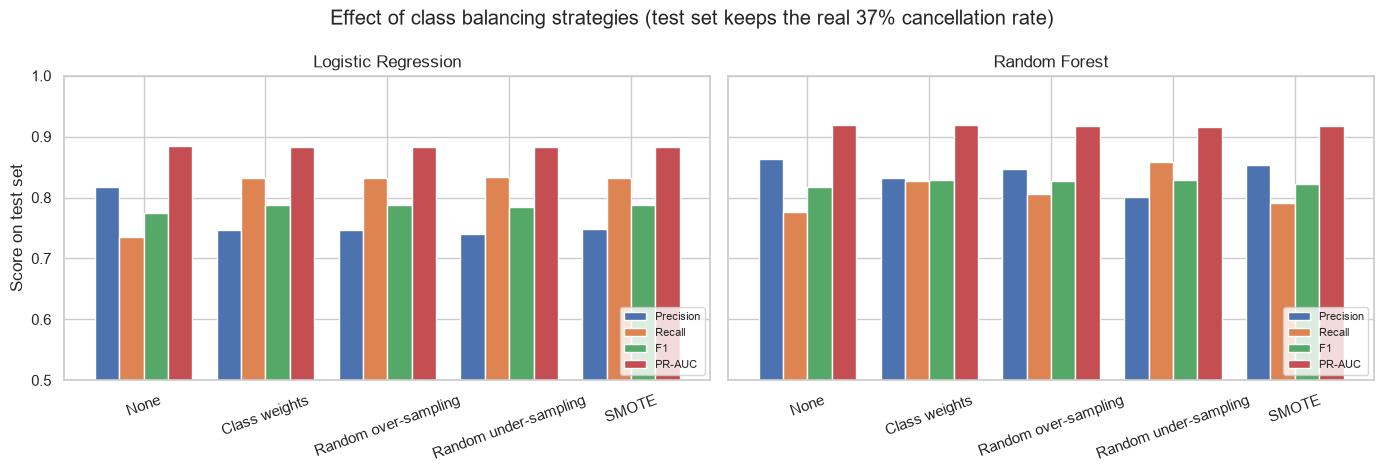


Class balancing experiment:
            Balancing               Model Training rows (0 / 1)     F1  Precision  Recall  ROC-AUC  PR-AUC  Train time (s)
                 None Logistic Regression       60,007 / 35,344 0.7745     0.8176  0.7357   0.9165  0.8840            1.36
                 None       Random Forest       60,007 / 35,344 0.8174     0.8624  0.7768   0.9432  0.9187            1.72
        Class weights Logistic Regression       60,007 / 35,344 0.7874     0.7468  0.8325   0.9165  0.8826            1.28
        Class weights       Random Forest       60,007 / 35,344 0.8294     0.8315  0.8273   0.9433  0.9187            1.65
 Random over-sampling Logistic Regression       60,007 / 60,007 0.7873     0.7466  0.8327   0.9164  0.8825            1.43
 Random over-sampling       Random Forest       60,007 / 60,007 0.8265     0.8475  0.8065   0.9424  0.9173            1.98
Random under-sampling Logistic Regression       35,344 / 35,344 0.7844     0.7408  0.8334   0.9167  0.8827    

In [7]:
# Cell 6: Class balancing (Table 4.6, Figure 4.1)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler

final_feats = reduced
n_neg, n_pos = int((y_tr == 0).sum()), int((y_tr == 1).sum())
train_sizes = {
    "None": (n_neg, n_pos), "Class weights": (n_neg, n_pos),
    "Random over-sampling": (n_neg, n_neg), "Random under-sampling": (n_pos, n_pos),
    "SMOTE": (n_neg, n_neg),
}


def model_for(m_name, weighted=False):
    cw = "balanced" if weighted else None
    if m_name == "Logistic Regression":
        return LogisticRegression(max_iter=3000, class_weight=cw)
    return RandomForestClassifier(n_estimators=100, n_jobs=-1,
                                  random_state=RANDOM_STATE, class_weight=cw)


def sampler_for(strategy):
    return {"Random over-sampling": RandomOverSampler(random_state=RANDOM_STATE),
            "Random under-sampling": RandomUnderSampler(random_state=RANDOM_STATE),
            "SMOTE": SMOTE(random_state=RANDOM_STATE)}.get(strategy)


strategies = ["None", "Class weights", "Random over-sampling", "Random under-sampling", "SMOTE"]
rows = []
for strategy in strategies:
    for m_name in ["Logistic Regression", "Random Forest"]:
        prep = lr_prep(final_feats) if m_name == "Logistic Regression" else rf_prep(final_feats)
        steps = [("prep", prep)]
        if sampler_for(strategy) is not None:
            steps.append(("sample", sampler_for(strategy)))
        steps.append(("model", model_for(m_name, weighted=(strategy == "Class weights"))))
        res = evaluate(ImbPipeline(steps), X_tr[final_feats], y_tr, X_te[final_feats], y_te)
        neg, pos = train_sizes[strategy]
        rows.append({"Balancing": strategy, "Model": m_name,
                     "Training rows (0 / 1)": f"{neg:,} / {pos:,}", **res})
        print(f"Done: {strategy} | {m_name}")

table_4_6 = pd.DataFrame(rows)
table_4_6.to_csv(TAB_DIR / "table4.6_balancing.csv", index=False)

# Figure 4.1: precision, recall, F1 and PR-AUC per strategy
metrics = ["Precision", "Recall", "F1", "PR-AUC"]
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), sharey=True)
for ax, m_name in zip(axes, ["Logistic Regression", "Random Forest"]):
    sub = table_4_6[table_4_6["Model"] == m_name].set_index("Balancing")[metrics]
    sub.plot(kind="bar", ax=ax, width=0.8, rot=20)
    ax.set_title(m_name)
    ax.set_xlabel("")
    ax.set_ylim(0.5, 1.0)
    ax.legend(fontsize=8, loc="lower right")
axes[0].set_ylabel("Score on test set")
fig.suptitle("Effect of class balancing strategies (test set keeps the real 37% cancellation rate)")
fig.tight_layout()
fig.savefig(FIG_DIR / "fig4.1_balancing.png", dpi=300)
plt.show()

# SMOTE check: synthetic rows with impossible (fractional) one-hot values
prep_chk = lr_prep(final_feats)
Z = prep_chk.fit_transform(X_tr[final_feats], y_tr)
Z = Z.toarray() if hasattr(Z, "toarray") else Z
cat_idx = [i for i, name in enumerate(prep_chk.get_feature_names_out()) if name.startswith("cat__")]
Z_res, _ = SMOTE(random_state=RANDOM_STATE).fit_resample(Z, y_tr)
synthetic = Z_res[len(Z):, :][:, cat_idx]
fractional = np.any((synthetic > 1e-9) & (synthetic < 1 - 1e-9), axis=1)

print("\nClass balancing experiment:")
print(table_4_6.to_string(index=False))
print(f"\nSMOTE check: {len(synthetic):,} synthetic rows created; "
      f"{fractional.sum():,} ({fractional.mean()*100:.2f}%) have impossible fractional category values")

Hold-out done: Logistic Regression
Hold-out done: Random Forest
Cross-validation done: Logistic Regression
Cross-validation done: Random Forest


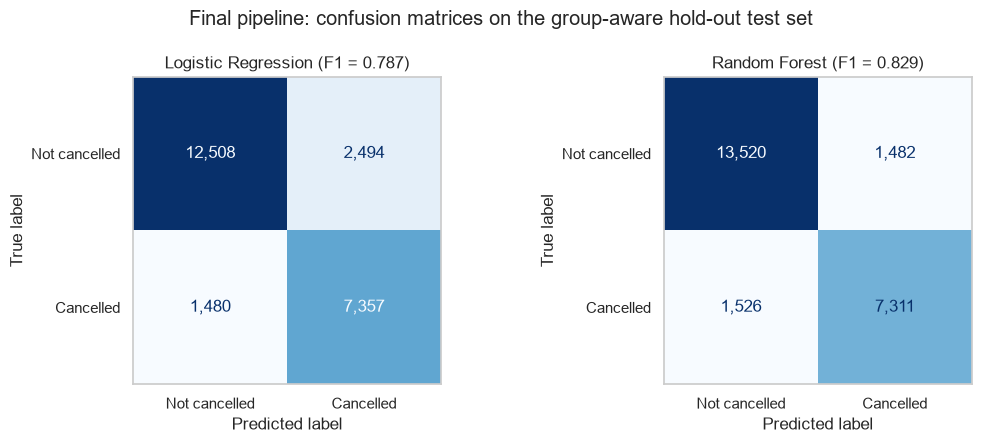


From baseline to final pipeline:
                                         Evaluation               Model              F1       Precision          Recall         ROC-AUC          PR-AUC
Task 2 baseline (random split, minimal preparation) Logistic Regression          0.7368          0.8049          0.6793          0.9030    not measured
 Honest baseline (group split, minimal preparation) Logistic Regression          0.7561          0.8147          0.7054          0.9081          0.8734
        Final pipeline (group split, hold-out test) Logistic Regression          0.7874          0.7468          0.8325          0.9165          0.8826
      Final pipeline (grouped 5-fold CV, mean ± SD) Logistic Regression 0.7815 ± 0.0032 0.7472 ± 0.0048 0.8192 ± 0.0081 0.9129 ± 0.0030 0.8770 ± 0.0038
Task 2 baseline (random split, minimal preparation)       Random Forest          0.8527          0.8836          0.8239          0.9597    not measured
 Honest baseline (group split, minimal preparation)   

In [14]:
# Cell 7: Final pipeline evaluation (Table 4.7, Figure 4.2)
from sklearn.metrics import ConfusionMatrixDisplay


def final_pipeline(m_name):
    prep = lr_prep(final_feats) if m_name == "Logistic Regression" else rf_prep(final_feats)
    return Pipeline([("prep", prep), ("model", model_for(m_name, weighted=True))])


model_names = ["Logistic Regression", "Random Forest"]
key_metrics = ["F1", "Precision", "Recall", "ROC-AUC", "PR-AUC"]

# 1. Hold-out evaluation (same test set as all experiments)
holdout = {}
for m_name in model_names:
    pipe = final_pipeline(m_name)
    holdout[m_name] = (pipe, evaluate(pipe, X_tr[final_feats], y_tr, X_te[final_feats], y_te))
    print(f"Hold-out done: {m_name}")

# 2. Grouped 5-fold cross-validation on the full cleaned dataset
X_all, y_all = df[final_feats], df[TARGET]
splits = list(sgkf.split(X_all, y_all, groups=group_id))
cv_results = {}
for m_name in model_names:
    fold_scores = {k: [] for k in key_metrics}
    for tr, te in splits:
        res = evaluate(final_pipeline(m_name), X_all.iloc[tr], y_all.iloc[tr],
                       X_all.iloc[te], y_all.iloc[te])
        for k in key_metrics:
            fold_scores[k].append(res[k])
    cv_results[m_name] = fold_scores
    print(f"Cross-validation done: {m_name}")

# Table 4.7: from the Task 2 baseline to the final pipeline
t21 = pd.read_csv(TAB_DIR / "table2.1_supervised_results.csv").set_index("Model")
t42 = pd.read_csv(TAB_DIR / "table4.2_duplicate_handling.csv")
t42 = t42[t42["Scenario"].str.startswith("B:")].set_index("Model")

rows = []
for m_name in model_names:
    rows.append({"Evaluation": "Task 2 baseline (random split, minimal preparation)", "Model": m_name,
                                "F1": f"{t21.loc[m_name, 'F1-score']:.4f}", **{k: f"{t21.loc[m_name, k]:.4f}" for k in ["Precision", "Recall", "ROC-AUC"]},
                 "PR-AUC": "not measured"})
    rows.append({"Evaluation": "Honest baseline (group split, minimal preparation)", "Model": m_name,
                 **{k: f"{t42.loc[m_name, k]:.4f}" for k in key_metrics}})
    rows.append({"Evaluation": "Final pipeline (group split, hold-out test)", "Model": m_name,
                 **{k: f"{holdout[m_name][1][k]:.4f}" for k in key_metrics}})
    rows.append({"Evaluation": "Final pipeline (grouped 5-fold CV, mean ± SD)", "Model": m_name,
                 **{k: f"{np.mean(v):.4f} ± {np.std(v):.4f}" for k, v in cv_results[m_name].items()}})

table_4_7 = pd.DataFrame(rows)
table_4_7.to_csv(TAB_DIR / "table4.7_final_evaluation.csv", index=False)

# Figure 4.2: confusion matrices of the final models on the hold-out test set
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, m_name in zip(axes, model_names):
    pred = (holdout[m_name][0].predict_proba(X_te[final_feats])[:, 1] >= 0.5).astype(int)
    ConfusionMatrixDisplay.from_predictions(
        y_te, pred, display_labels=["Not cancelled", "Cancelled"],
        values_format=",d", cmap="Blues", colorbar=False, ax=ax)
    ax.set_title(f"{m_name} (F1 = {holdout[m_name][1]['F1']:.3f})")
    ax.grid(False)
fig.suptitle("Final pipeline: confusion matrices on the group-aware hold-out test set")
fig.tight_layout()
fig.savefig(FIG_DIR / "fig4.2_final_confusion_matrices.png", dpi=300)
plt.show()

print("\nFrom baseline to final pipeline:")
print(table_4_7.to_string(index=False))

Saved Table 4.8 with 16 techniques


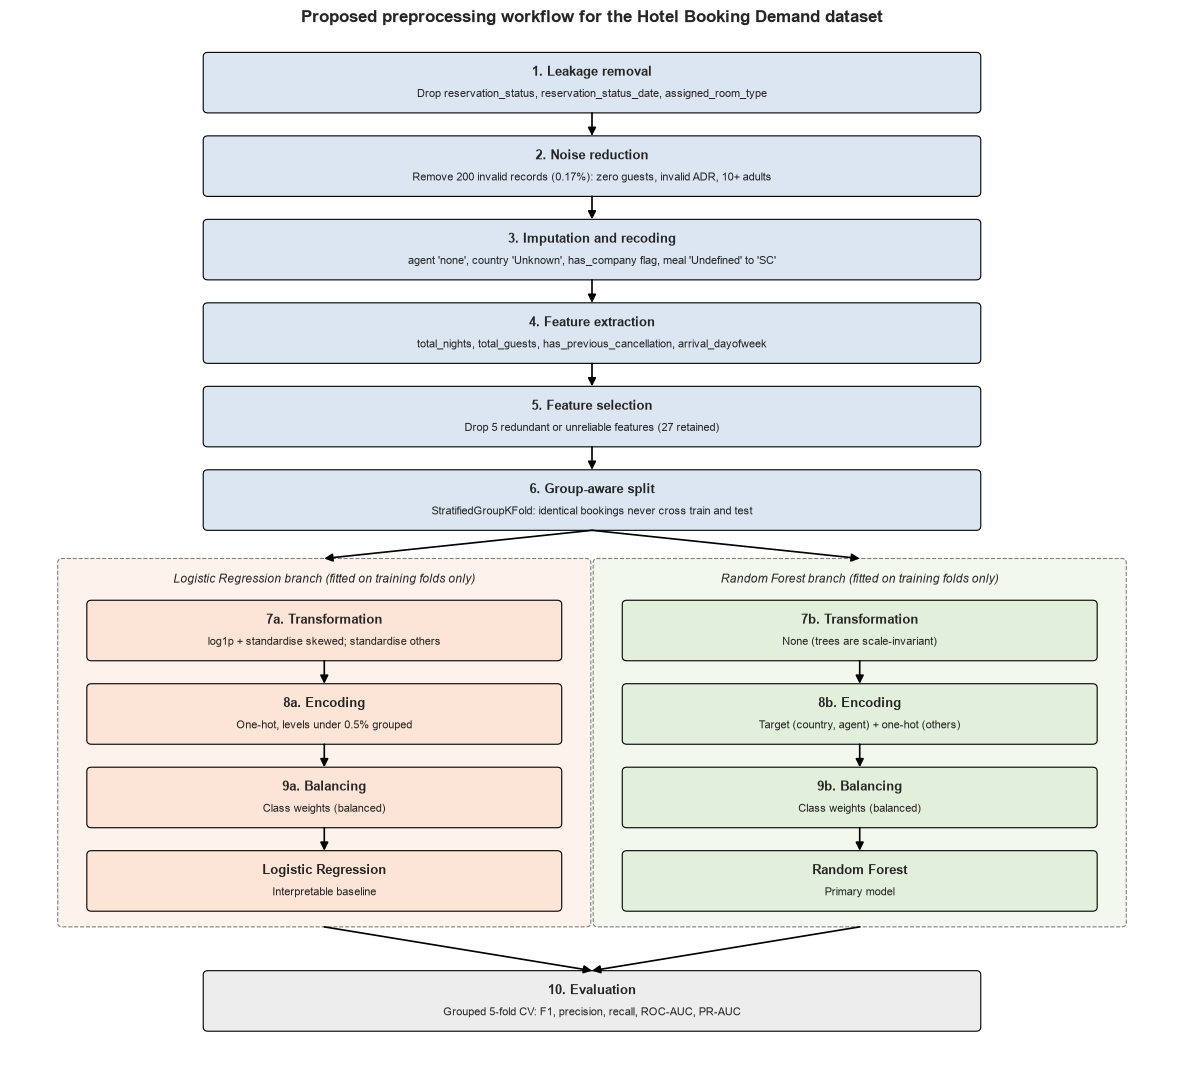

In [11]:
# Cell 8: Technique evaluation table (Table 4.8) and pipeline diagram (Figure 4.3)
from matplotlib.patches import FancyBboxPatch

table_4_8 = pd.DataFrame([
    ("Missing value imputation", "Cleaning",
     "Replaces missing entries so all records can be used",
     "Missingness is informative (agent missing: 24.7% vs 39.0% cancelled)",
     "Explicit 'none' / 'Unknown' categories and has_company flag preserve this signal",
     "Mean or mode imputation would erase the signal; deletion would bias the class balance",
     "Adopted (category-based)"),
    ("Duplicate removal", "Cleaning",
     "Removes repeated records that overweight some patterns",
     "26.8% duplicates, mostly genuine group bookings",
     "RF F1 0.8235 kept vs 0.8248 removed; base rate falls from 37.1% to 27.6%",
     "Deletes real bookings and shifts the base rate; the real problem was evaluation leakage",
     "Rejected; group-aware split used instead"),
    ("Noise reduction", "Cleaning",
     "Removes invalid records that contradict domain rules",
     "Only 200 records (0.17%) are clearly invalid",
     "Negligible effect on metrics; removes impossible bookings",
     "Aggressive IQR removal would delete informative extremes (e.g. 91.6% cancel rate)",
     "Adopted (rule-based only)"),
    ("Standardisation", "Transformation",
     "Rescales features to mean 0 and standard deviation 1",
     "Needed for LR; unscaled LR failed to converge in 3,000 iterations",
     "LR F1 0.7415 to 0.7561; training time 31.46 s to 1.47 s",
     "Sensitive to outliers; no benefit for tree models",
     "Adopted for LR"),
    ("Normalisation (min-max)", "Transformation",
     "Rescales features to the range 0 to 1",
     "Heavy tails compress most values into a narrow range",
     "LR F1 0.7535, slightly below standardisation, and slower convergence",
     "Highly sensitive to extreme values",
     "Rejected"),
    ("Log transformation", "Transformation",
     "log(1 + x) compresses large values and reduces right skew",
     "Several features are strongly right-skewed (adr 10.53)",
     "LR F1 0.7561 to 0.7739, PR-AUC 0.8734 to 0.8840",
     "Overcorrected adr skew to -3.74; negative values must be clipped",
     "Adopted for LR (skewed features)"),
    ("Power transformation (Yeo-Johnson)", "Transformation",
     "Estimates a per-feature power that makes distributions more symmetric",
     "Best skew reduction in Task 3 (adr 10.53 to 0.41)",
     "LR F1 0.7709, statistically tied with log1p",
     "Parameters estimated from data; slower (5.58 s) and less interpretable",
     "Rejected in favour of simpler log1p"),
    ("Feature selection", "Feature engineering",
     "Keeps a subset of features to reduce redundancy and noise",
     "Redundant pairs (V up to 0.88) and unreliable features found in Task 3",
     "All options within 0.003 F1; L1 kept 45 of 110 LR features",
     "L1 selection depends on untuned C; may drop one of a correlated pair arbitrarily",
     "Adopted (domain-driven removal of 5 features)"),
    ("Feature extraction", "Feature engineering",
     "Derives new features from existing ones",
     "Stay length and party size are spread across several columns",
     "Enabled removal of component features without loss (Table 4.5)",
     "Adds collinearity if originals are kept",
     "Adopted (4 derived features)"),
    ("Dimensionality reduction (PCA)", "Feature engineering",
     "Projects data onto components retaining maximum variance",
     "Mixed binary and continuous features; target not considered",
     "LR F1 0.7739 to 0.7567; RF F1 0.8220 to 0.7862",
     "Variance is not predictive signal; destroys interpretability",
     "Rejected"),
    ("One-hot encoding", "Feature engineering",
     "Creates one binary column per category",
     "Required for nominal categories in LR; 552 columns with all levels",
     "Rare-level grouping: 110 columns for only 0.004 lower F1",
     "Dimensionality explodes for country and agent; sparse input slows RF",
     "Adopted (rare levels grouped)"),
    ("Target encoding", "Feature engineering",
     "Replaces each category with its cross-fitted mean target value",
     "Suits high-cardinality country and agent",
     "RF F1 unchanged (0.8217 vs 0.8220) with 11x faster training",
     "Target leakage unless cross-fitted; less useful for LR (F1 0.7630)",
     "Adopted for RF (country, agent)"),
    ("SMOTE", "Balancing",
     "Creates synthetic minority samples by interpolating between neighbours",
     "Moderate imbalance (1.70:1); categorical features dominate",
     "No gain; LR training 35x slower; lowest balanced RF F1 (0.8214)",
     "42.24% of synthetic rows had impossible category values",
     "Rejected"),
    ("Random over-sampling", "Balancing",
     "Duplicates minority samples until classes are equal",
     "Minority class already large (35,344 training rows)",
     "Similar to class weights (LR F1 0.7873)",
     "Exact copies encourage overfitting, as with duplicates",
     "Rejected"),
    ("Random under-sampling", "Balancing",
     "Discards majority samples until classes are equal",
     "Would remove 24,663 real bookings",
     "Highest RF recall (0.8580) but lowest precision (0.8008)",
     "Information loss; more false alarms",
     "Rejected"),
    ("Class weights", "Balancing",
     "Increases the loss penalty for minority-class errors",
     "Keeps all real data; no synthetic records",
     "Best RF F1 (0.8294); LR recall 0.7357 to 0.8325",
     "Lowers precision; best threshold depends on business costs",
     "Adopted"),
], columns=["Technique", "Category", "Theoretical basis", "Suitability for this dataset",
            "Measured impact", "Risks and limitations", "Decision"])
table_4_8.to_csv(TAB_DIR / "table4.8_technique_evaluation.csv", index=False)
print(f"Saved Table 4.8 with {len(table_4_8)} techniques")

# Figure 4.3: final preprocessing workflow
fig, ax = plt.subplots(figsize=(12, 11))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")
H = 0.05


def box(x, y, w, title, text, color):
    ax.add_patch(FancyBboxPatch((x - w / 2, y - H / 2), w, H, boxstyle="round,pad=0.004",
                                fc=color, ec="black", lw=0.8, zorder=2))
    ax.text(x, y + 0.010, title, ha="center", va="center", fontsize=9.5, weight="bold", zorder=4)
    ax.text(x, y - 0.011, text, ha="center", va="center", fontsize=8, zorder=4)


def arrow(x1, y1, x2, y2):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1), zorder=3,
                arrowprops=dict(arrowstyle="-|>", color="black", lw=1.2,
                                shrinkA=0, shrinkB=0, mutation_scale=12))


common = [
    ("1. Leakage removal", "Drop reservation_status, reservation_status_date, assigned_room_type"),
    ("2. Noise reduction", "Remove 200 invalid records (0.17%): zero guests, invalid ADR, 10+ adults"),
    ("3. Imputation and recoding", "agent 'none', country 'Unknown', has_company flag, meal 'Undefined' to 'SC'"),
    ("4. Feature extraction", "total_nights, total_guests, has_previous_cancellation, arrival_dayofweek"),
    ("5. Feature selection", "Drop 5 redundant or unreliable features (27 retained)"),
    ("6. Group-aware split", "StratifiedGroupKFold: identical bookings never cross train and test"),
]
ys = [0.95 - i * 0.08 for i in range(len(common))]
for (title, text), y in zip(common, ys):
    box(0.5, y, 0.66, title, text, "#DCE6F2")
for y1, y2 in zip(ys[:-1], ys[1:]):
    arrow(0.5, y1 - H / 2 - 0.004, 0.5, y2 + H / 2 + 0.004)

# Branch panels with labels inside, so arrows never cross text
panel_top, panel_bottom = 0.49, 0.145
branches = {
    0.27: ("Logistic Regression branch (fitted on training folds only)", "#FCE4D6", "#FDF3EC", [
        ("7a. Transformation", "log1p + standardise skewed; standardise others"),
        ("8a. Encoding", "One-hot, levels under 0.5% grouped"),
        ("9a. Balancing", "Class weights (balanced)"),
        ("Logistic Regression", "Interpretable baseline")]),
    0.73: ("Random Forest branch (fitted on training folds only)", "#E2EFDA", "#F2F8EE", [
        ("7b. Transformation", "None (trees are scale-invariant)"),
        ("8b. Encoding", "Target (country, agent) + one-hot (others)"),
        ("9b. Balancing", "Class weights (balanced)"),
        ("Random Forest", "Primary model")]),
}
branch_ys = [0.425, 0.345, 0.265, 0.185]
for x, (label, box_color, panel_color, stages) in branches.items():
    ax.add_patch(FancyBboxPatch((x - 0.225, panel_bottom), 0.45, panel_top - panel_bottom,
                                boxstyle="round,pad=0.004", fc=panel_color, ec="grey",
                                lw=0.8, ls="--", zorder=1))
    ax.text(x, panel_top - 0.016, label, ha="center", va="center",
            fontsize=8.5, style="italic", zorder=4)
    arrow(0.5, ys[-1] - H / 2 - 0.004, x, panel_top + 0.004)
    for (title, text), y in zip(stages, branch_ys):
        box(x, y, 0.40, title, text, box_color)
    for y1, y2 in zip(branch_ys[:-1], branch_ys[1:]):
        arrow(x, y1 - H / 2 - 0.004, x, y2 + H / 2 + 0.004)
    arrow(x, panel_bottom - 0.004, 0.5, 0.07 + H / 2 + 0.004)

box(0.5, 0.07, 0.66, "10. Evaluation",
    "Grouped 5-fold CV: F1, precision, recall, ROC-AUC, PR-AUC", "#EDEDED")
ax.set_title("Proposed preprocessing workflow for the Hotel Booking Demand dataset",
             fontsize=12, weight="bold")
fig.tight_layout()
fig.savefig(FIG_DIR / "fig4.3_preprocessing_workflow.png", dpi=300)
plt.show()

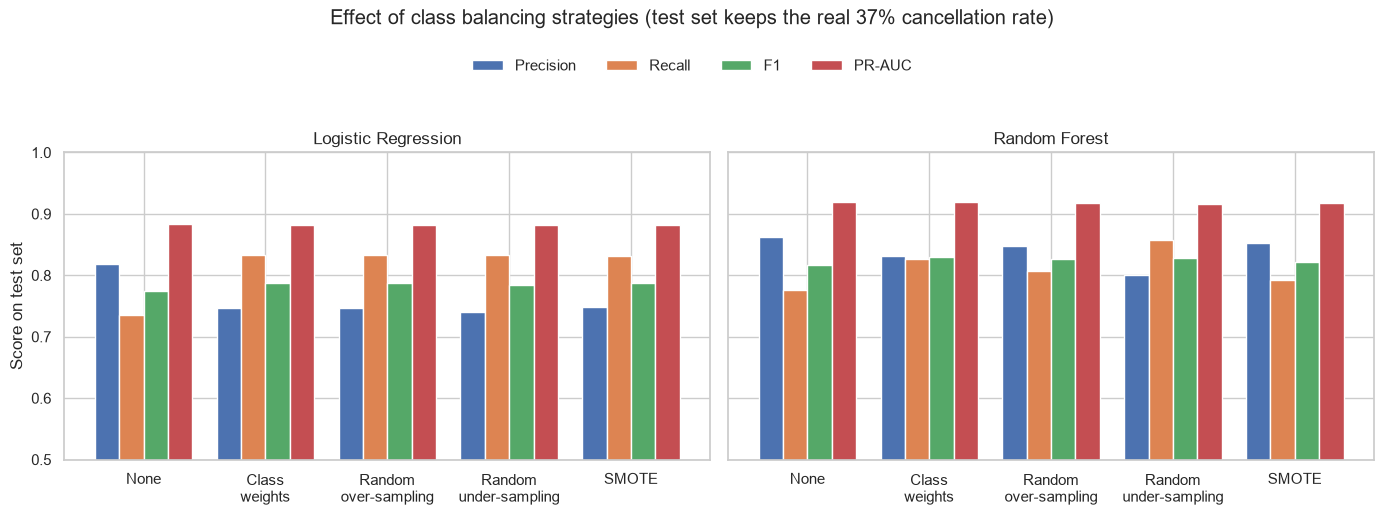

In [13]:
# Cell 9: Redraw Figure 4.1 with a shared legend above the panels (from saved results)
t46 = pd.read_csv(TAB_DIR / "table4.6_balancing.csv", keep_default_na=False)
metrics = ["Precision", "Recall", "F1", "PR-AUC"]
short_names = {"None": "None", "Class weights": "Class\nweights",
               "Random over-sampling": "Random\nover-sampling",
               "Random under-sampling": "Random\nunder-sampling", "SMOTE": "SMOTE"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2), sharey=True)
for ax, m_name in zip(axes, ["Logistic Regression", "Random Forest"]):
    sub = t46[t46["Model"] == m_name].set_index("Balancing")[metrics]
    sub.index = [short_names[s] for s in sub.index]
    sub.plot(kind="bar", ax=ax, width=0.8, rot=0, legend=False)
    ax.set_title(m_name)
    ax.set_xlabel("")
    ax.set_ylim(0.5, 1.0)
axes[0].set_ylabel("Score on test set")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=4, bbox_to_anchor=(0.5, 0.92),
           frameon=False)
fig.suptitle("Effect of class balancing strategies (test set keeps the real 37% cancellation rate)",
             y=0.99)
fig.tight_layout(rect=[0, 0, 1, 0.86])
fig.savefig(FIG_DIR / "fig4.1_balancing.png", dpi=300)
plt.show()